In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [3]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
import warnings
warnings.filterwarnings('ignore')

In [4]:
df = pd.read_csv(r'D:\ML_Files\Google_PlayStore_App_data\googleplaystore.csv')

In [5]:
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [6]:
df.columns


Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver'],
      dtype='object')

In [7]:
df.shape

(10841, 13)

In [8]:
print("Number of rows:", df.shape[0], "Number of columns:", df.shape[1])

Number of rows: 10841 Number of columns: 13


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


## Now here we have columns that are marked as categorical so we have to convert it into numerical



# First convert size to numerical


In [10]:
df['Size'].unique()

array(['19M', '14M', '8.7M', '25M', '2.8M', '5.6M', '29M', '33M', '3.1M',
       '28M', '12M', '20M', '21M', '37M', '2.7M', '5.5M', '17M', '39M',
       '31M', '4.2M', '7.0M', '23M', '6.0M', '6.1M', '4.6M', '9.2M',
       '5.2M', '11M', '24M', 'Varies with device', '9.4M', '15M', '10M',
       '1.2M', '26M', '8.0M', '7.9M', '56M', '57M', '35M', '54M', '201k',
       '3.6M', '5.7M', '8.6M', '2.4M', '27M', '2.5M', '16M', '3.4M',
       '8.9M', '3.9M', '2.9M', '38M', '32M', '5.4M', '18M', '1.1M',
       '2.2M', '4.5M', '9.8M', '52M', '9.0M', '6.7M', '30M', '2.6M',
       '7.1M', '3.7M', '22M', '7.4M', '6.4M', '3.2M', '8.2M', '9.9M',
       '4.9M', '9.5M', '5.0M', '5.9M', '13M', '73M', '6.8M', '3.5M',
       '4.0M', '2.3M', '7.2M', '2.1M', '42M', '7.3M', '9.1M', '55M',
       '23k', '6.5M', '1.5M', '7.5M', '51M', '41M', '48M', '8.5M', '46M',
       '8.3M', '4.3M', '4.7M', '3.3M', '40M', '7.8M', '8.8M', '6.6M',
       '5.1M', '61M', '66M', '79k', '8.4M', '118k', '44M', '695k', '1.6M',
     

here in size we have three categories 
1. size in mb
2. size in kb
3. size as Varies with device

In [11]:
#check the values containing M in Size column
df['Size'].loc[df['Size'].str.contains('M')].value_counts()

Size
11M      198
12M      196
14M      194
13M      191
15M      184
17M      160
19M      154
16M      149
26M      149
25M      143
20M      139
21M      138
24M      136
10M      136
18M      133
23M      117
22M      114
29M      103
27M       97
28M       95
30M       84
33M       79
3.3M      77
37M       76
35M       72
31M       70
2.9M      69
2.5M      68
2.3M      68
2.8M      65
3.4M      65
3.7M      63
34M       63
32M       63
3.9M      62
3.8M      62
40M       62
4.0M      61
44M       61
3.0M      61
36M       60
48M       59
46M       59
4.2M      59
5.0M      58
3.6M      57
39M       56
3.1M      56
3.2M      55
38M       55
4.3M      54
2.7M      53
4.1M      52
5.4M      51
2.0M      51
3.5M      51
4.9M      50
2.6M      50
1.8M      50
1.5M      48
2.4M      48
5.7M      48
41M       48
43M       47
4.6M      46
6.3M      45
2.2M      45
49M       45
5.3M      44
50M       44
53M       43
5.1M      43
4.4M      42
1.2M      41
63M       41
42M       41
1.7M   

In [12]:
#check the values containing K in Size column
df['Size'].loc[df['Size'].str.contains('k')].value_counts()

Size
375k     3
118k     3
201k     3
79k      3
266k     3
51k      2
192k     2
141k     2
592k     2
172k     2
842k     2
417k     2
206k     2
17k      2
335k     2
26k      2
70k      2
58k      2
948k     2
323k     2
29k      2
72k      2
656k     2
228k     2
33k      2
957k     2
364k     2
196k     2
18k      2
334k     2
704k     2
473k     2
318k     2
992k     1
253k     1
420k     1
404k     1
980k     1
696k     1
544k     1
525k     1
920k     1
779k     1
853k     1
720k     1
713k     1
772k     1
241k     1
857k     1
953k     1
865k     1
251k     1
930k     1
540k     1
313k     1
746k     1
203k     1
314k     1
239k     1
371k     1
220k     1
730k     1
756k     1
91k      1
293k     1
74k      1
14k      1
317k     1
78k      1
924k     1
902k     1
818k     1
81k      1
939k     1
169k     1
45k      1
475k     1
965k     1
545k     1
61k      1
283k     1
655k     1
714k     1
93k      1
872k     1
121k     1
322k     1
976k     1
238k     1
549k     1
954k 

In [13]:
df['Size'].loc[df['Size'].str.contains('k')].value_counts().sum()

np.int64(316)

In [14]:
df['Size'].loc[df['Size'].str.contains('k')].value_counts().sum()

np.int64(316)

In [15]:


def convert_size(size):
    # 1. Handle missing values (floats) first!
    if isinstance(size, str):
            if size == 'Varies with device':
                return np.nan
            elif 'M' in size:
                return float(size.replace('M', '')) * 1024*1024
            elif 'k' in size:
                return float(size.replace('k', ''))*1024
    
    return size  # Handle any other cases

In [16]:
df['Size'] = df['Size'].apply(convert_size)

In [17]:
df['Size']


0         19922944.0
1         14680064.0
2          9122611.2
3         26214400.0
4          2936012.8
5          5872025.6
6         19922944.0
7         30408704.0
8         34603008.0
9          3250585.6
10        29360128.0
11        12582912.0
12        20971520.0
13        22020096.0
14        38797312.0
15         2831155.2
16         5767168.0
17        17825792.0
18        40894464.0
19        32505856.0
20        14680064.0
21        12582912.0
22         4404019.2
23         7340032.0
24        24117248.0
25         6291456.0
26        26214400.0
27         6396313.6
28         4823449.6
29         4404019.2
30         9646899.2
31         5452595.2
32        11534336.0
33        11534336.0
34         4404019.2
35         9646899.2
36        25165824.0
37               NaN
38        11534336.0
39         9856614.4
40        15728640.0
41        10485760.0
42               NaN
43         1258291.2
44        12582912.0
45        25165824.0
46        27262976.0
47         83

In [18]:
# renaming the  column Size to Size_in_Bytes for better understanding
df.rename(columns={'Size':'Size_in_Bytes'}, inplace=True)

In [19]:
df.head()

,App,Category,Rating,Reviews,Size_in_Bytes,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19922944.0,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14680064.0,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,9122611.2,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,26214400.0,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2936012.8,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [20]:
df['Size_in_Bytes'] = pd.to_numeric(df['Size_in_Bytes'], errors='coerce')

In [21]:
#also converting Size in mega bytes
df['Size_in_MegaBytes'] = df['Size_in_Bytes'].apply(lambda x: x/(1024*1024))

In [22]:
df.head()


,App,Category,Rating,Reviews,Size_in_Bytes,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Size_in_MegaBytes
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19922944.0,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up,19.0
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14680064.0,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,14.0
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,9122611.2,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up,8.7
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,26214400.0,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up,25.0
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2936012.8,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up,2.8


In [23]:
# Now looking into Installs column
df['Installs'].unique()

array(['10,000+', '500,000+', '5,000,000+', '50,000,000+', '100,000+',
       '50,000+', '1,000,000+', '10,000,000+', '5,000+', '100,000,000+',
       '1,000,000,000+', '1,000+', '500,000,000+', '50+', '100+', '500+',
       '10+', '1+', '5+', '0+', '0', 'Free'], dtype=object)

In [24]:
# I think ust if we remove the + and , from the values it will be good to convert them into numeric values
df['Installs'] = df['Installs'].str.replace('+','').str.replace(',','')
#we also have to convert it into numeric values
df['Installs'] = pd.to_numeric(df['Installs'], errors='coerce')

In [25]:
df['Installs']

0        1.000000e+04
1        5.000000e+05
2        5.000000e+06
3        5.000000e+07
4        1.000000e+05
5        5.000000e+04
6        5.000000e+04
7        1.000000e+06
8        1.000000e+06
9        1.000000e+04
10       1.000000e+06
11       1.000000e+06
12       1.000000e+07
13       1.000000e+05
14       1.000000e+05
15       5.000000e+03
16       5.000000e+05
17       1.000000e+04
18       5.000000e+06
19       1.000000e+07
20       1.000000e+05
21       1.000000e+05
22       5.000000e+05
23       1.000000e+05
24       5.000000e+04
25       1.000000e+04
26       5.000000e+05
27       1.000000e+05
28       1.000000e+04
29       1.000000e+05
30       1.000000e+05
31       5.000000e+04
32       1.000000e+05
33       1.000000e+05
34       1.000000e+04
35       1.000000e+05
36       5.000000e+05
37       5.000000e+06
38       1.000000e+04
39       5.000000e+05
40       1.000000e+04
41       1.000000e+05
42       1.000000e+07
43       1.000000e+05
44       1.000000e+04
45       1

In [26]:
df['Installs'].isnull().value_counts()

Installs
False    10840
True         1
Name: count, dtype: int64

In [27]:
df.dropna(subset=['Installs'], inplace=True)

In [28]:
df['Installs'].isnull().value_counts()

Installs
False    10840
Name: count, dtype: int64

In [29]:
df['Installs'] = df['Installs'].apply(lambda x: int(x))

In [30]:
df['Installs']

0             10000
1            500000
2           5000000
3          50000000
4            100000
5             50000
6             50000
7           1000000
8           1000000
9             10000
10          1000000
11          1000000
12         10000000
13           100000
14           100000
15             5000
16           500000
17            10000
18          5000000
19         10000000
20           100000
21           100000
22           500000
23           100000
24            50000
25            10000
26           500000
27           100000
28            10000
29           100000
30           100000
31            50000
32           100000
33           100000
34            10000
35           100000
36           500000
37          5000000
38            10000
39           500000
40            10000
41           100000
42         10000000
43           100000
44            10000
45         10000000
46           100000
47           100000
48           100000
49           100000


In [31]:
df['Price'].unique()

array(['0', '$4.99', '$3.99', '$6.99', '$1.49', '$2.99', '$7.99', '$5.99',
       '$3.49', '$1.99', '$9.99', '$7.49', '$0.99', '$9.00', '$5.49',
       '$10.00', '$24.99', '$11.99', '$79.99', '$16.99', '$14.99',
       '$1.00', '$29.99', '$12.99', '$2.49', '$10.99', '$1.50', '$19.99',
       '$15.99', '$33.99', '$74.99', '$39.99', '$3.95', '$4.49', '$1.70',
       '$8.99', '$2.00', '$3.88', '$25.99', '$399.99', '$17.99',
       '$400.00', '$3.02', '$1.76', '$4.84', '$4.77', '$1.61', '$2.50',
       '$1.59', '$6.49', '$1.29', '$5.00', '$13.99', '$299.99', '$379.99',
       '$37.99', '$18.99', '$389.99', '$19.90', '$8.49', '$1.75',
       '$14.00', '$4.85', '$46.99', '$109.99', '$154.99', '$3.08',
       '$2.59', '$4.80', '$1.96', '$19.40', '$3.90', '$4.59', '$15.46',
       '$3.04', '$4.29', '$2.60', '$3.28', '$4.60', '$28.99', '$2.95',
       '$2.90', '$1.97', '$200.00', '$89.99', '$2.56', '$30.99', '$3.61',
       '$394.99', '$1.26', '$1.20', '$1.04'], dtype=object)

In [32]:
df.loc[df['Price'].str.contains('\$')].value_counts().sum()

np.int64(577)

In [33]:
df['Price']=df['Price'].apply(lambda x: x.replace('$','') if '$' in x else x)
df['Price']=df['Price'].apply(lambda x: float(x))

In [34]:
df['Price'].value_counts()

Price
0.00      10040
0.99        148
2.99        129
1.99         73
4.99         72
3.99         63
1.49         46
5.99         30
2.49         26
9.99         21
6.99         13
399.99       12
14.99        11
4.49          9
29.99         7
3.49          7
7.99          7
24.99         7
5.49          6
19.99         6
6.49          5
8.99          5
12.99         5
11.99         5
10.00         3
1.00          3
16.99         3
2.00          3
17.99         2
10.99         2
9.00          2
79.99         2
7.49          2
3.95          2
33.99         2
1.70          2
13.99         2
8.49          2
39.99         2
1.50          1
25.99         1
74.99         1
15.99         1
3.88          1
1.76          1
3.02          1
400.00        1
4.84          1
2.50          1
1.59          1
1.61          1
4.77          1
5.00          1
1.29          1
379.99        1
299.99        1
37.99         1
18.99         1
389.99        1
19.90         1
1.75          1
14.00         1
4.

In [35]:
df.isnull().sum()

App                     0
Category                0
Rating               1474
Reviews                 0
Size_in_Bytes        1695
Installs                0
Type                    1
Price                   0
Content Rating          0
Genres                  0
Last Updated            0
Current Ver             8
Android Ver             2
Size_in_MegaBytes    1695
dtype: int64

In [36]:
(df.isnull().sum()) / len(df)*100

App                   0.000000
Category              0.000000
Rating               13.597786
Reviews               0.000000
Size_in_Bytes        15.636531
Installs              0.000000
Type                  0.009225
Price                 0.000000
Content Rating        0.000000
Genres                0.000000
Last Updated          0.000000
Current Ver           0.073801
Android Ver           0.018450
Size_in_MegaBytes    15.636531
dtype: float64

In [37]:
bins = [-1, 1000, 100000, 1000000, 10000000,float('inf')]  # float('inf') means upto infinity
labels = ['Micro', 'Small', 'Medium', 'Large', 'Mega']
df['Installs_Category']=pd.cut(df['Installs'], bins=bins, labels=labels)

In [38]:
df['Installs'].describe()

count    1.084000e+04
mean     1.546434e+07
std      8.502936e+07
min      0.000000e+00
25%      1.000000e+03
50%      1.000000e+05
75%      5.000000e+06
max      1.000000e+09
Name: Installs, dtype: float64

In [39]:
df.groupby('Installs_Category')['Rating'].describe()

,count,mean,std,min,25%,50%,75%,max
Installs_Category,,,,,,,,
Micro,1360.0,4.198897,0.833518,1.0,3.9,4.4,4.8,5.0
Small,3059.0,4.065839,0.555041,1.4,3.8,4.2,4.5,5.0
Medium,2115.0,4.207470,0.376423,1.8,4.0,4.3,4.5,4.9
Large,2004.0,4.287076,0.294902,2.0,4.1,4.3,4.5,4.9
Mega,828.0,4.374396,0.193726,3.1,4.3,4.4,4.5,4.8


In [40]:
#now I wanna fill the missing value in Reviews column based on Installs_Category mean value 
#here null values are not filled just by taking mean either they are filed based on the category of Installs
df['Reviews'] = pd.to_numeric(df['Reviews'], errors='coerce')
df['Reviews'] = df.groupby('Installs_Category')['Reviews'].transform(lambda x: x.fillna(x.mean()))

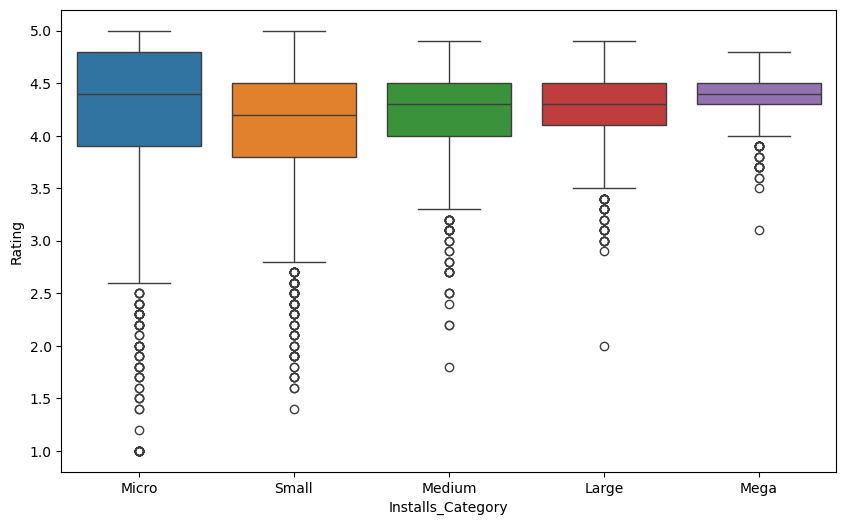

In [41]:
plt.figure(figsize=(10,6))
sns.boxplot(x='Installs_Category', y='Rating', hue='Installs_Category', data=df)
plt.show()

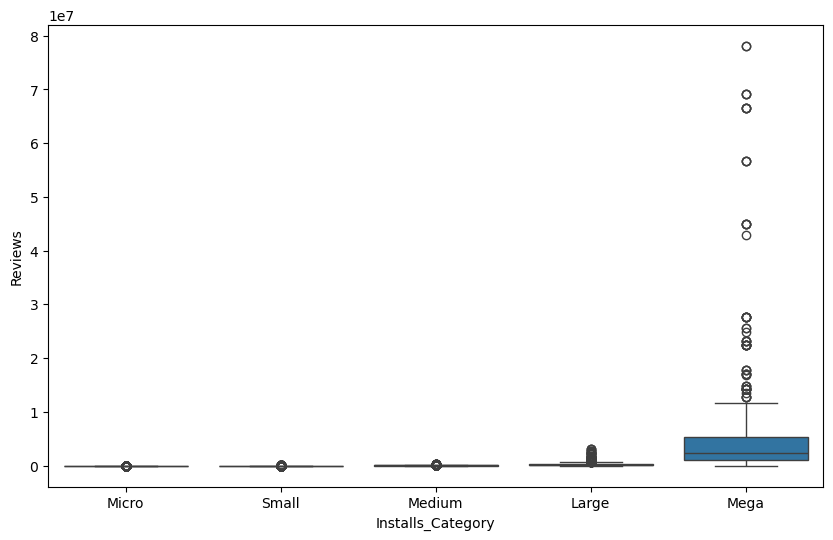

In [42]:
plt.figure(figsize=(10,6))
sns.boxplot(x='Installs_Category', y='Reviews', data=df)
plt.show()

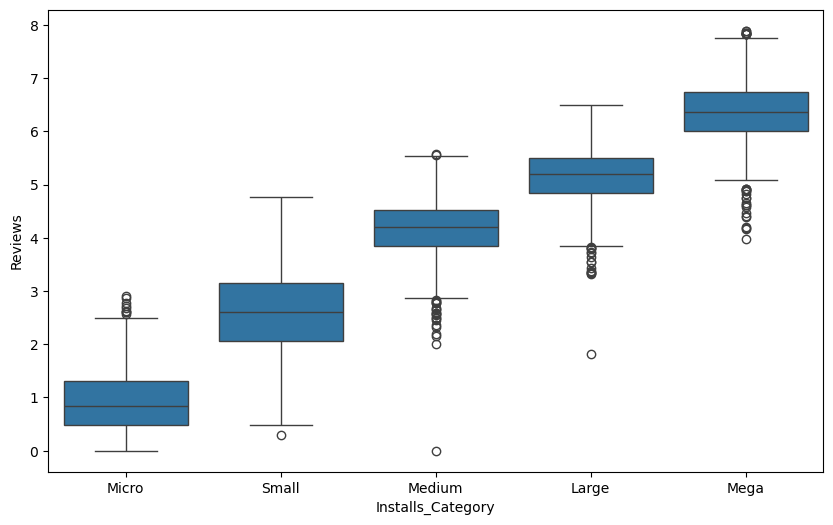

In [43]:
#Now see that here values of Reviews are increasing as the Installs_Category is increasing so we will use 
# log to normalize the Reviews column as by using log just scale reduces but the impact of the values remains same 
# and data also becomes more normally distributed

plt.figure(figsize=(10,6))
sns.boxplot(x='Installs_Category', y=np.log10(df['Reviews']), data=df)
plt.show()

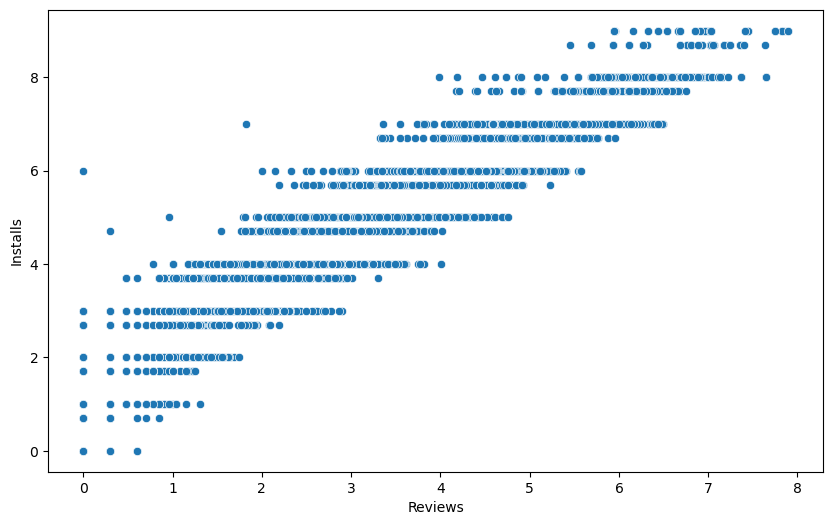

In [44]:
# Now I will draw scatter plot of Installs and reviews to see their relationship but after log transformation of Reviews
plt.figure(figsize=(10,6))  
sns.scatterplot(x=np.log10(df['Reviews']),y=np.log10(df['Installs']), data=df)
plt.show()

<Figure size 1000x600 with 0 Axes>

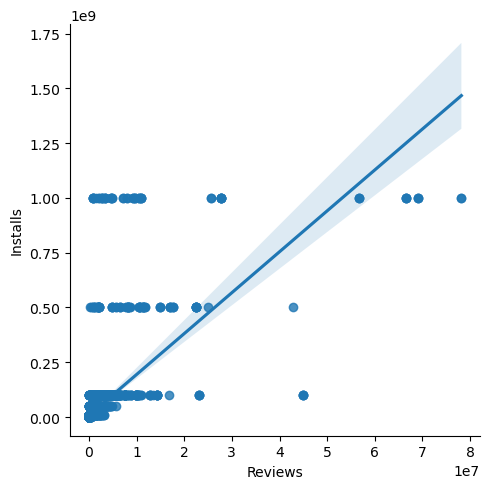

In [45]:
plt.figure(figsize=(10,6))  
sns.lmplot(x='Reviews',y='Installs', data=df)
plt.show()

In [46]:
# means while as the number of reviews increases the number of installs also increases

# Now looking towards Duplicated values

In [47]:
print(f"Duplicated values in df: {df.duplicated().sum()}")

Duplicated values in df: 483


In [48]:
for col in df.columns:
    print(f"{col}: {df.duplicated().sum()}")

App: 483
Category: 483
Rating: 483
Reviews: 483
Size_in_Bytes: 483
Installs: 483
Type: 483
Price: 483
Content Rating: 483
Genres: 483
Last Updated: 483
Current Ver: 483
Android Ver: 483
Size_in_MegaBytes: 483
Installs_Category: 483


Look the duplicated values

In [49]:
df[df['App'].duplicated(keep=False)].sort_values(by='App')

,App,Category,Rating,Reviews,Size_in_Bytes,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Size_in_MegaBytes,Installs_Category
1393,10 Best Foods for You,HEALTH_AND_FITNESS,4.0,2490,3984588.8,500000,Free,0.00,Everyone 10+,Health & Fitness,"February 17, 2017",1.9,2.3.3 and up,3.800000,Medium
1407,10 Best Foods for You,HEALTH_AND_FITNESS,4.0,2490,3984588.8,500000,Free,0.00,Everyone 10+,Health & Fitness,"February 17, 2017",1.9,2.3.3 and up,3.800000,Medium
2543,1800 Contacts - Lens Store,MEDICAL,4.7,23160,27262976.0,1000000,Free,0.00,Everyone,Medical,"July 27, 2018",7.4.1,5.0 and up,26.000000,Medium
2322,1800 Contacts - Lens Store,MEDICAL,4.7,23160,27262976.0,1000000,Free,0.00,Everyone,Medical,"July 27, 2018",7.4.1,5.0 and up,26.000000,Medium
2385,2017 EMRA Antibiotic Guide,MEDICAL,4.4,12,3984588.8,1000,Paid,16.99,Everyone,Medical,"January 27, 2017",1.0.5,4.0.3 and up,3.800000,Micro
2256,2017 EMRA Antibiotic Guide,MEDICAL,4.4,12,3984588.8,1000,Paid,16.99,Everyone,Medical,"January 27, 2017",1.0.5,4.0.3 and up,3.800000,Micro
1337,21-Day Meditation Experience,HEALTH_AND_FITNESS,4.4,11506,15728640.0,100000,Free,0.00,Everyone,Health & Fitness,"August 2, 2018",3.0.0,4.1 and up,15.000000,Small
1434,21-Day Meditation Experience,HEALTH_AND_FITNESS,4.4,11506,15728640.0,100000,Free,0.00,Everyone,Health & Fitness,"August 2, 2018",3.0.0,4.1 and up,15.000000,Small
3083,365Scores - Live Scores,SPORTS,4.6,666521,26214400.0,10000000,Free,0.00,Everyone,Sports,"July 29, 2018",5.5.9,4.1 and up,25.000000,Large
5415,365Scores - Live Scores,SPORTS,4.6,666246,26214400.0,10000000,Free,0.00,Everyone,Sports,"July 29, 2018",5.5.9,4.1 and up,25.000000,Large


In [50]:
df.drop_duplicates(inplace=True)

## Checking Insights

Q1: Which category has highest number of apps

In [51]:
df['Category'].value_counts().head(10)


Category
FAMILY             1943
GAME               1121
TOOLS               843
BUSINESS            427
MEDICAL             408
PRODUCTIVITY        407
PERSONALIZATION     388
LIFESTYLE           373
COMMUNICATION       366
FINANCE             360
Name: count, dtype: int64

Q2: Which category has highest number of installs

In [52]:
df.groupby('Category')['Installs'].sum().sort_values(ascending=False)

Category
GAME                   31544024415
COMMUNICATION          24152276251
SOCIAL                 12513867902
PRODUCTIVITY           12463091369
TOOLS                  11452771915
FAMILY                 10041692505
PHOTOGRAPHY             9721247655
TRAVEL_AND_LOCAL        6361887146
VIDEO_PLAYERS           6222002720
NEWS_AND_MAGAZINES      5393217760
SHOPPING                2573348785
ENTERTAINMENT           2455660000
PERSONALIZATION         2074494782
BOOKS_AND_REFERENCE     1916469576
SPORTS                  1528574498
HEALTH_AND_FITNESS      1361022512
BUSINESS                 863664865
FINANCE                  770348734
MAPS_AND_NAVIGATION      724281890
LIFESTYLE                534823539
EDUCATION                533952000
WEATHER                  426100520
FOOD_AND_DRINK           257898751
DATING                   206536107
HOUSE_AND_HOME           125212461
ART_AND_DESIGN           124338100
LIBRARIES_AND_DEMO        62995910
COMICS                    56086150
AUTO_AND_VE

Q3: Categories with highest reviews

In [53]:
df.groupby('Category')['Reviews'].sum().sort_values(ascending=False)

Category
GAME                   1415536650
COMMUNICATION           601273552
SOCIAL                  533576829
FAMILY                  396771969
TOOLS                   273185044
PHOTOGRAPHY             204297410
VIDEO_PLAYERS           110380188
PRODUCTIVITY            102554498
SHOPPING                 94931162
PERSONALIZATION          75193163
SPORTS                   65322708
TRAVEL_AND_LOCAL         55565160
ENTERTAINMENT            47570716
NEWS_AND_MAGAZINES       38245873
HEALTH_AND_FITNESS       30845186
MAPS_AND_NAVIGATION      30659254
EDUCATION                23165500
BOOKS_AND_REFERENCE      21873227
FINANCE                  16999891
WEATHER                  14604735
LIFESTYLE                12820575
BUSINESS                 12358171
FOOD_AND_DRINK            7671576
DATING                    5545397
COMICS                    3383276
HOUSE_AND_HOME            2794772
ART_AND_DESIGN            1714440
MEDICAL                   1396757
AUTO_AND_VEHICLES         1163666
LIBRA

Q4: Categories with highest Average Ratings

In [54]:
df.groupby('Category')['Rating'].mean().sort_values(ascending=False)

Category
EVENTS                 4.435556
EDUCATION              4.375969
ART_AND_DESIGN         4.358065
BOOKS_AND_REFERENCE    4.347458
PERSONALIZATION        4.333871
PARENTING              4.300000
GAME                   4.281285
BEAUTY                 4.278571
HEALTH_AND_FITNESS     4.261450
SOCIAL                 4.254918
SHOPPING               4.251485
WEATHER                4.244000
SPORTS                 4.225175
PRODUCTIVITY           4.201796
FAMILY                 4.191153
AUTO_AND_VEHICLES      4.190411
PHOTOGRAPHY            4.182895
MEDICAL                4.182450
LIBRARIES_AND_DEMO     4.178462
HOUSE_AND_HOME         4.164706
FOOD_AND_DRINK         4.164151
COMICS                 4.155172
COMMUNICATION          4.151466
ENTERTAINMENT          4.136036
NEWS_AND_MAGAZINES     4.128505
FINANCE                4.127445
BUSINESS               4.102593
LIFESTYLE              4.096066
TRAVEL_AND_LOCAL       4.094146
VIDEO_PLAYERS          4.063750
MAPS_AND_NAVIGATION    4.051613

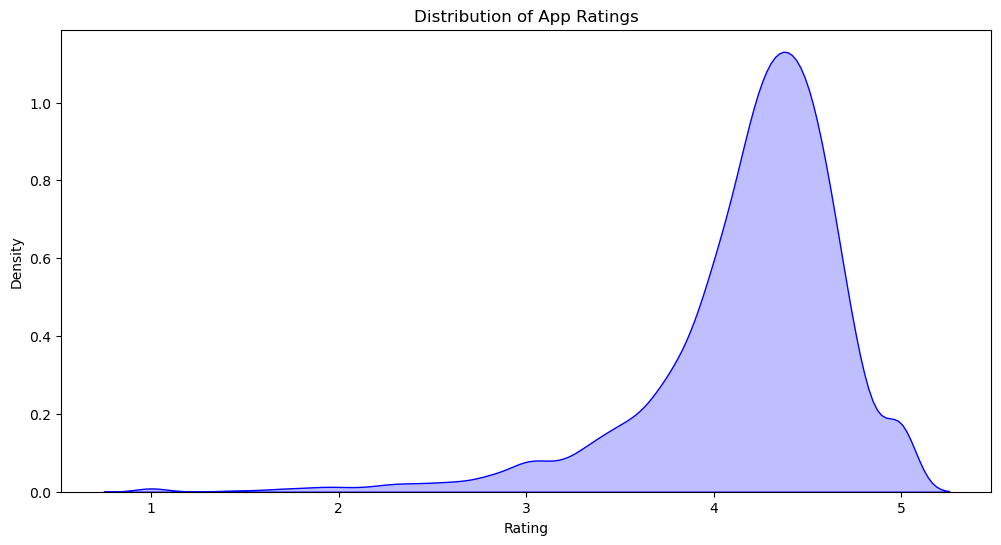

In [55]:
plt.figure(figsize=(12,6))
sns.kdeplot(df['Rating'], color='blue', shade=True)
plt.title('Distribution of App Ratings')
plt.xlabel('Rating')    
plt.show()

In [56]:
df.shape

(10357, 15)

# So out of 10357 maximum people gave ratings between 4 to 5 

In [57]:
#Top paid apps based on Rating
top_paid_apps = df[df['Type'] == 'Paid'].sort_values(by=['Rating'], ascending=False).head(10)
top_paid_apps[['App', 'Category', 'Rating', 'Type']]

,App,Category,Rating,Type
10697,Mu.F.O.,GAME,5.0,Paid
8287,AC DC Power Monitor,LIFESTYLE,5.0,Paid
7466,211:CK,GAME,5.0,Paid
9056,Santa's Monster Shootout DX,GAME,5.0,Paid
9010,RETRO Shocked DW-6000,PERSONALIZATION,5.0,Paid
9039,Chronolink DX,FAMILY,5.0,Paid
2271,FHR 5-Tier 2.0,MEDICAL,5.0,Paid
2262,Super Hearing Secret Voices Recorder PRO,MEDICAL,5.0,Paid
7477,USMLE Step 2 CK Flashcards,FAMILY,5.0,Paid
8526,DL Image Manager,PRODUCTIVITY,5.0,Paid


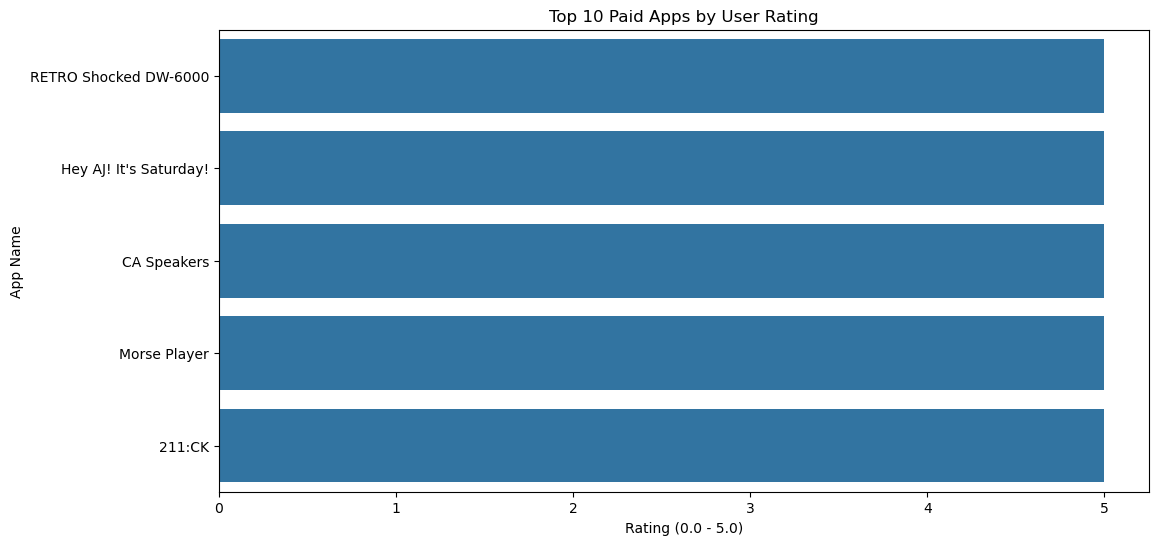

In [58]:
paid_df = df[df['Type'] == 'Paid']

# 2. Sort by Rating (Primary) and Reviews (Secondary) 
# We use Reviews as a tie-breaker so popular apps rank higher than apps with only 1 rating
top_paid_apps = paid_df.sort_values(by=['Rating', 'Reviews'], ascending=False).head(5)

plt.figure(figsize=(12, 6))
sns.barplot(x='Rating', y='App', data=top_paid_apps)

plt.title('Top 10 Paid Apps by User Rating')
plt.xlabel('Rating (0.0 - 5.0)')
plt.ylabel('App Name')
plt.show()

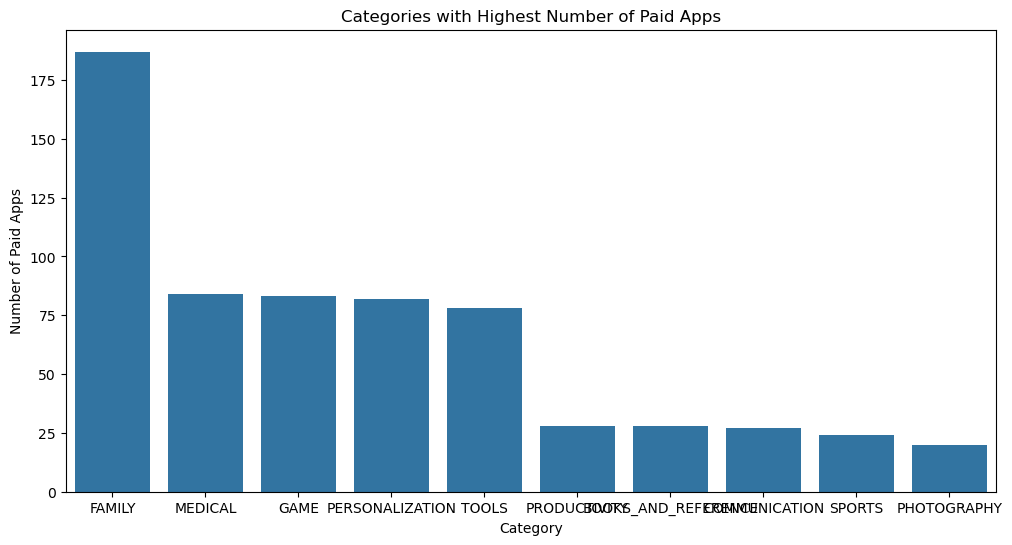

In [59]:
# To see which categories have the MOST paid apps
paid_counts = df[df['Type'] == 'Paid']['Category'].value_counts().head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=paid_counts.index, y=paid_counts.values)
plt.title('Categories with Highest Number of Paid Apps')
plt.ylabel('Number of Paid Apps')
plt.show()

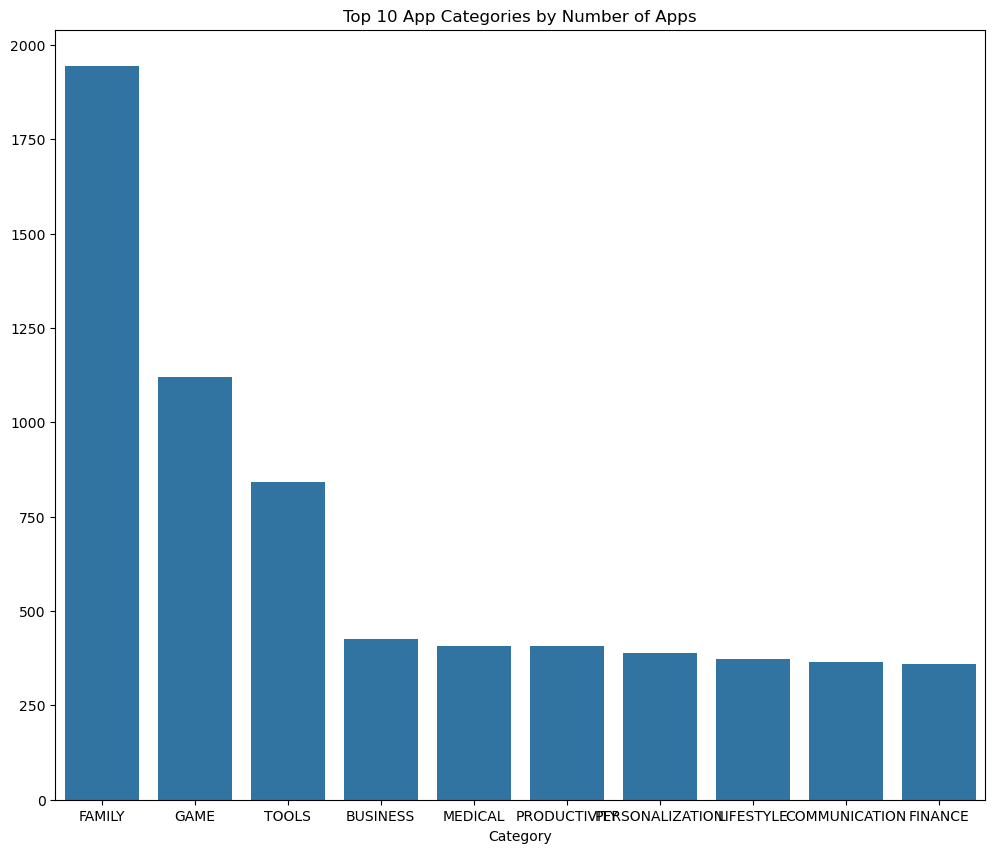

In [60]:
plt.figure(figsize=(12,10))
sns.barplot(x=df['Category'].value_counts().head(10).index, y=df['Category'].value_counts().head(10).values)
plt.title('Top 10 App Categories by Number of Apps')
plt.xlabel('Category')
plt.show()

In [61]:
df.groupby('Type')['Installs'].count()

Type
Free    9591
Paid     765
Name: Installs, dtype: int64

Q:which category installed more paid apps

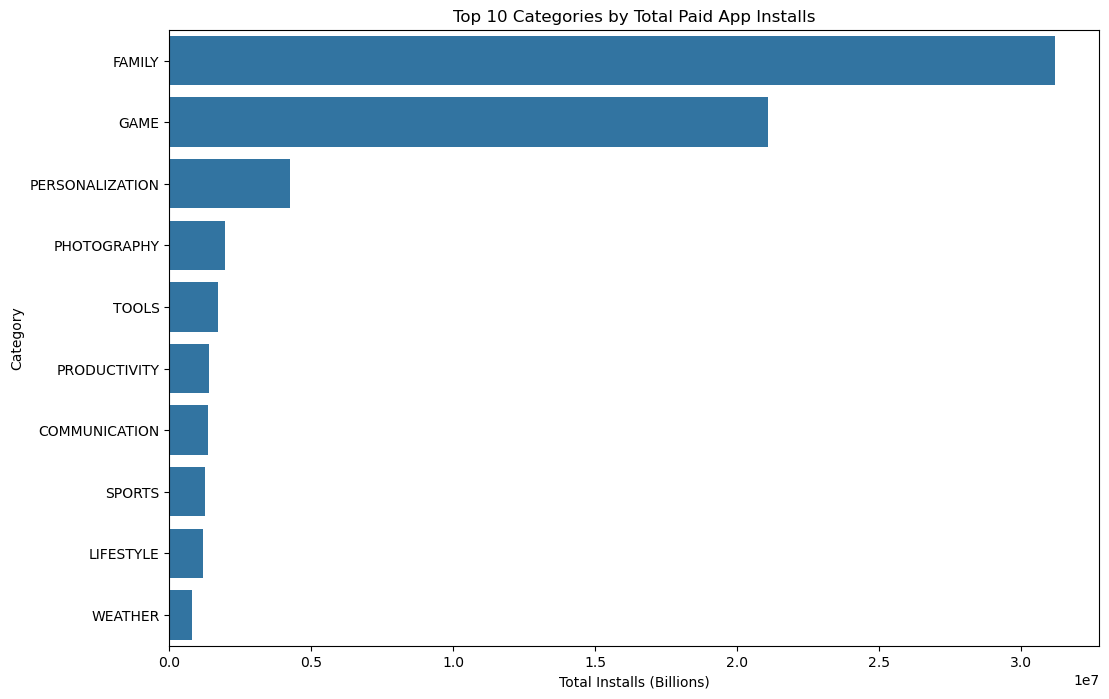

In [62]:
# 1. Filter for Paid apps only
paid_apps = df[df['Type'] == 'Paid']

# 2. Group by Category and sum the Installs
# We sort to ensure the categories with the most installs are at the top
category_installs = paid_apps.groupby('Category')['Installs'].sum().sort_values(ascending=False).head(10)

# 3. Plotting
plt.figure(figsize=(12, 8))
sns.barplot(x=category_installs.values, y=category_installs.index)

plt.title('Top 10 Categories by Total Paid App Installs')
plt.xlabel('Total Installs (Billions)')
plt.ylabel('Category')
plt.show()

In [63]:
paid_counts = df[df['Type'] == 'Paid']['Category'].value_counts().head(10)
paid_counts

Category
FAMILY                 187
MEDICAL                 84
GAME                    83
PERSONALIZATION         82
TOOLS                   78
PRODUCTIVITY            28
BOOKS_AND_REFERENCE     28
COMMUNICATION           27
SPORTS                  24
PHOTOGRAPHY             20
Name: count, dtype: int64